In [9]:
import pandas as pd

dataset = pd.read_csv("50_Startups.csv")
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [16]:
dataset = pd.get_dummies(dataset).astype(int)
dataset.drop(columns=['State_California'])

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349,136897,471784,192261,0,1
1,162597,151377,443898,191792,0,0
2,153441,101145,407934,191050,1,0
3,144372,118671,383199,182901,0,1
4,142107,91391,366168,166187,1,0
5,131876,99814,362861,156991,0,1
6,134615,147198,127716,156122,0,0
7,130298,145530,323876,155752,1,0
8,120542,148718,311613,152211,0,1
9,123334,108679,304981,149759,0,0


In [17]:
independent = dataset[['R&D Spend','Administration','Marketing Spend','State_Florida','State_New York']]
dependent = dataset[['Profit']]

In [18]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(independent, dependent, test_size=0.3, random_state=0)

In [43]:
from sklearn.tree import DecisionTreeRegressor #importing the Linear regression library from sklearn
regressor = DecisionTreeRegressor(criterion='squared_error', splitter='best')
# regressor = DecisionTreeRegressor(criterion='absolute_error', splitter='best')
# regressor = DecisionTreeRegressor(criterion='poisson', splitter='best')

# regressor = DecisionTreeRegressor(criterion='squared_error', splitter='random')
# regressor = DecisionTreeRegressor(criterion='absolute_error', splitter='random')
# regressor = DecisionTreeRegressor(criterion='poisson', splitter='random')
regressor.fit(X_train, Y_train)

,criterion,'absolute_error'
,splitter,'random'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


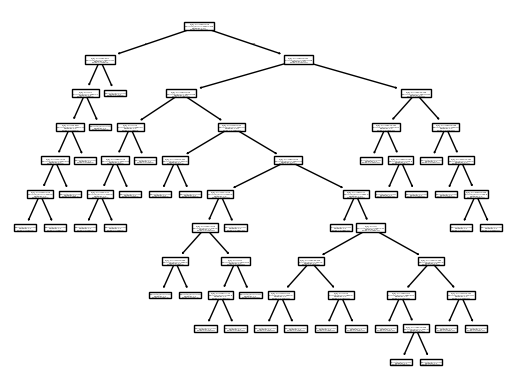

In [44]:
from matplotlib import pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [45]:
Y_pred = regressor.predict(X_test)
Y_pred

array([108733., 141585., 141585.,  90708., 182901., 101004.,  71498.,
        81005., 108733., 182901.,  89949.,  89949., 118474.,  89949.,
       132602.])

In [46]:
from sklearn.metrics import r2_score # for r2 score evaluvation importing the function from metrics library

r_score= r2_score(Y_test,Y_pred) # comparing the predicted values and test(Actual) values to calculate R2Score 
r_score

0.9087224570462922